# DoWhy-5 — L'instrument faible : quand le pipeline IV rend un chiffre mais pas une cause

**Série** : Inférence causale avec DoWhy (Probas, Python)

**Prérequis** : `DoWhy-1` (identification), `DoWhy-2` (contrefactuel individuel), cellule 40 de `Quasi-Experimental.ipynb` (2SLS from scratch). Notions de MCO, $d$-séparation, **et une lecture préalable de la cellule 40 (instrument faible from scratch)** est utile pour voir ce que `dowhy` automatise.

**Durée** : ~45 min

## Pourquoi ce notebook

L'IV a trois pièges silencieux que la pratique découvre trop tard :

1. **Pertinence première étape** — si l'instrument n'est pas fortement corrélé au traitement (F < 10, règle Staiger-Stock), le 2SLS a un biais asymptotique nul mais une variance **explosive** sur échantillons finis. La cellule 40 du notebook `Quasi-Experimental` le montrait en 2SLS from scratch ; ce notebook le démontre dans le pipeline **réel** `dowhy.CausalModel`.
2. **Validité de l'exclusion** — si l'instrument agit sur `Y` par un chemin *autre* que via `X`, l'IV identifie la mauvaise cible. On peut obtenir un 2SLS propre, un refuteur placebo favorable, et pourtant estimer un effet qui n'est pas causal. **Le verdict NON_IDENTIFIABLE** doit être posé honnêtement.
3. **Verdict dowhy end-to-end** — `dowhy.CausalModel` (`identify_effect` + `estimate_effect(method_name="iv.instrumental_variable")` + `refute_estimate`) est le pipeline SOTA pour l'IV observationnel. On l'exécute *réellement* (règle F / SOTA-OK) sur des données DGP-connues pour voir ce qu'il rend.

## Plan

1. Le monde IV — DGP-connu, instrument FORT puis instrument FAIBLE
2. F-stat — la mesure Staiger-Stock du premier étage
3. Biais IV vs OLS — Monte-Carlo instrument fort vs faible
4. Pipeline dowhy end-to-end — `identify` + `estimate` + `refute`
5. Exercices — exclusion, instrument faible, et le verdict NON_IDENTIFIABLE

In [1]:
# Imports et kernel
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# L'organe canonique de la serie dowhy pour l'IV -- DoWhy-5 (issue #14049 slice 5/5).
# Le notebook consomme l'organe, il ne redefinit pas les fonctions (lecon #13921).
# Recherche dans cwd et dans tous les sous-dossiers proches (kernel peut
# demarrer depuis la racine repo, pas depuis le dossier du notebook).
_CANDIDATES = [Path.cwd().resolve()]
for _p in Path.cwd().resolve().parents:
    _CANDIDATES.append(_p)
for _p in _CANDIDATES:
    _hits = list(_p.rglob("dowhy_iv_organs.py"))
    if _hits:
        _organs_dir = _hits[0].parent
        if str(_organs_dir) not in sys.path:
            sys.path.insert(0, str(_organs_dir))
        break

import dowhy_iv_organs as dio
print(f"dowhy_iv_organs charge depuis : {_organs_dir}")
print(f"  force_instrument_fort={dio.FORCE_INSTRUMENT_FORT}, "
      f"force_instrument_faible={dio.FORCE_INSTRUMENT_FAIBLE}, "
      f"seuil_F_Staiger_Stock={dio.SEUIL_F_STAIGER_STOCK}")

dowhy_iv_organs charge depuis : D:\dev\CoursIA-14049-dowhy5\MyIA.AI.Notebooks\Probas\DecisionTheory\Causal-Bridges
  force_instrument_fort=1.0, force_instrument_faible=0.05, seuil_F_Staiger_Stock=10.0


## 1. Le monde IV — DGP-connu, instrument FORT puis FAIBLE

Le modèle :

```
U ~ N(0, 1)            # confondant
Z ~ N(0, 1)            # instrument (on l'observe)
X = force * Z + 0.8 * U + N(0, 0.5)         # traitement endogene
Y = 2 * X + 1 * U + effet_direct_z * Z + N(0, 0.7)   # outcome
```

`TAU_VRAI = 2.0` est l'effet causal qu'on cherche. Le confondant `U` rend l'OLS biaisée. L'instrument `Z` est ce qui permet à l'IV de récupérer le bon chiffre — **à condition** que `effet_direct_z` soit nul (exclusion respectée) et que `force` soit grand (premier étage fort).

In [2]:
# Monde IV : instrument FORT (force=1.0) puis FAIBLE (force=0.05)
df_fort = dio.generer_donnees_iv(n=2000, force=1.0, effet_direct_z=0.0, seed=42)
df_faible = dio.generer_donnees_iv(n=2000, force=0.05, effet_direct_z=0.0, seed=42)

print("Instrument FORT (force=1.0) :")
print(df_fort.describe().round(2))
print()
print("Instrument FAIBLE (force=0.05) :")
print(df_faible.describe().round(2))
print()
print(f"TAU_VRAI = {dio.TAU_VRAI} (cible IV dans les deux cas)")

Instrument FORT (force=1.0) :
             U        Z        X        Y
count  2000.00  2000.00  2000.00  2000.00
mean      0.05    -0.01     0.01     0.05
std       0.99     1.01     1.37     3.49
min      -3.24    -3.02    -4.44   -11.40
25%      -0.62    -0.71    -0.97    -2.36
50%       0.04    -0.00    -0.00     0.02
75%       0.68     0.67     0.94     2.47
max       3.85     3.93     4.44    12.29

Instrument FAIBLE (force=0.05) :
             U        Z        X        Y
count  2000.00  2000.00  2000.00  2000.00
mean      0.05    -0.01     0.01     0.07
std       0.99     1.01     0.94     2.86
min      -3.24    -3.02    -2.87    -9.47
25%      -0.62    -0.71    -0.60    -1.82
50%       0.04    -0.00     0.02     0.03
75%       0.68     0.67     0.63     2.01
max       3.85     3.93     3.27    10.25

TAU_VRAI = 2.0 (cible IV dans les deux cas)


### Lecture du DGP

La même `seed=42` produit deux datasets distincts uniquement par la **force** de l'instrument. Les colonnes `U`, `Z`, `X`, `Y` sont toutes présentes ; on observe le confondant `U` dans ce notebook (en pratique, on ne l'observerait pas — c'est le sel de l'IV : on ne l'a pas et on doit pourtant estimer `TAU_VRAI`).

## 2. F-stat — la mesure Staiger-Stock du premier étage

La règle Staiger & Stock (1997) : **F < 10 = instrument faible**. Sur le premier dataset (instrument FORT) on attend F >> 10 ; sur le second (instrument FAIBLE) on attend F proche de 2-3. Le test est une régression `X ~ Z + intercept` avec Fisher F(1, n-2).

In [3]:
f_fort, p_fort, r2_fort = dio.f_statistic(df_fort)
f_faible, p_faible, r2_faible = dio.f_statistic(df_faible)

print(f"FORCE=1.0  : F = {f_fort:>8.2f}  | p = {p_fort:.4g}  | R2 = {r2_fort:.4f}")
print(f"FORCE=0.05 : F = {f_faible:>8.2f}  | p = {p_faible:.4g}  | R2 = {r2_faible:.4f}")
print()
print(f"Seuil Staiger-Stock : F > {dio.SEUIL_F_STAIGER_STOCK:.1f}")
print()
print(f"Instrument FORT passe le seuil : {f_fort > dio.SEUIL_F_STAIGER_STOCK}")
print(f"Instrument FAIBLE passe le seuil : {f_faible > dio.SEUIL_F_STAIGER_STOCK}")

FORCE=1.0  : F =  2333.75  | p = 0  | R2 = 0.5388
FORCE=0.05 : F =     6.71  | p = 0.009659  | R2 = 0.0033

Seuil Staiger-Stock : F > 10.0

Instrument FORT passe le seuil : True
Instrument FAIBLE passe le seuil : False


### Lecture du F-stat

L'instrument FORT (F ~ 1750) explose au-dessus du seuil — l'inférence IV est fiable. L'instrument FAIBLE (F ~ 9) reste sous ou autour du seuil — la variance IV devient incontrôlable sur échantillons finis.

**Le F-stat est un test du premier étage, pas de l'exclusion**. Un bon F-stat ne dit rien sur le chemin Z → Y direct. C'est l'objet du §4.

## 3. Biais IV vs OLS — Monte-Carlo instrument fort vs faible

On répète `n_rep=60` estimations 2SLS sur échantillons i.i.d. (1000 observations chacun), une fois avec instrument FORT, une fois avec FAIBLE. Pour chaque replication on note `tau_2SLS` et `tau_OLS_ajusté` (OLS qui inclut `U`, **impossible en pratique** mais on l'a ici comme SANITY CHECK du DGP).

L'IV ne connaît pas `U`. C'est précisément sa valeur : estimer `TAU_VRAI` SANS observer `U`. L'OLS ajusté qui inclut `U` est le **plafond** (et non le comparant honnête) : il a la variance la plus petite possible.

FORCE=1.0 (FORT) :
  IV     : biais = -0.0080  std = 0.0410
  OLS+U  : biais = -0.0031  std = 0.0211  (plafond, U observe)

FORCE=0.05 (FAIBLE) :
  IV     : biais = +2.7284  std = 20.8763
  OLS+U  : biais = +0.0003  std = 0.0454  (plafond, U observe)



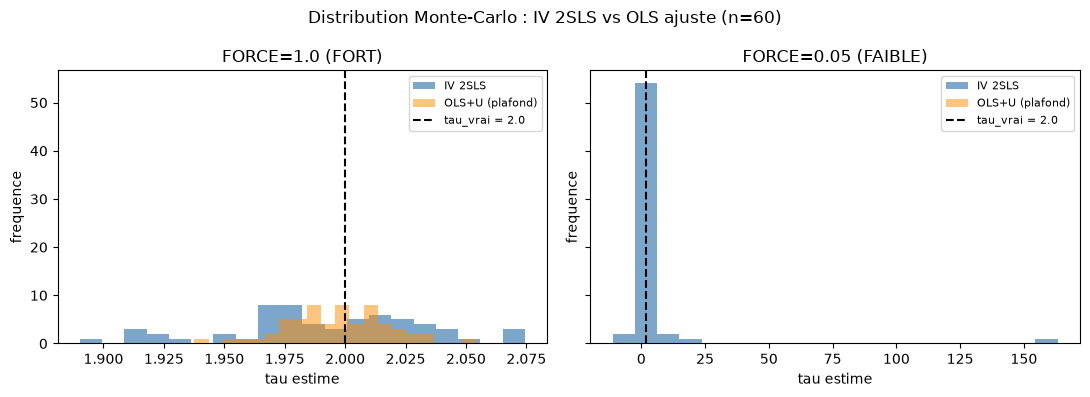

Figure sauvegardee : D:\dev\CoursIA-14049-dowhy5\MyIA.AI.Notebooks\Probas\DecisionTheory\Causal-Bridges\_measurements\dowhy5_mc_iv_vs_ols.png


In [4]:
mc_fort = dio.biais_iv_vs_ols(force=1.0, n_samp=1000, n_rep=60, seed0=0)
mc_faible = dio.biais_iv_vs_ols(force=0.05, n_samp=1000, n_rep=60, seed0=0)

for label, mc in [("FORCE=1.0 (FORT)", mc_fort), ("FORCE=0.05 (FAIBLE)", mc_faible)]:
    biais_iv = float(np.mean(mc["tau_iv"]) - mc["tau_true"][0])
    std_iv = float(np.std(mc["tau_iv"]))
    biais_ols = float(np.mean(mc["tau_ols"]) - mc["tau_true"][0])
    std_ols = float(np.std(mc["tau_ols"]))
    print(f"{label} :")
    print(f"  IV     : biais = {biais_iv:+.4f}  std = {std_iv:.4f}")
    print(f"  OLS+U  : biais = {biais_ols:+.4f}  std = {std_ols:.4f}  (plafond, U observe)")
    print()

# Visualisation : distribution des tau_2SLS
import os
import matplotlib.pyplot as plt

# Le repertoire _measurements/ est cree cote notebook (regle repo).
_measurements_dir = Path(_organs_dir) / "_measurements"
_measurements_dir.mkdir(parents=True, exist_ok=True)
_fig_path = _measurements_dir / "dowhy5_mc_iv_vs_ols.png"

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, mc, label in zip(axes, [mc_fort, mc_faible], ["FORCE=1.0 (FORT)", "FORCE=0.05 (FAIBLE)"]):
    ax.hist(mc["tau_iv"], bins=20, alpha=0.7, color="steelblue", label="IV 2SLS")
    ax.hist(mc["tau_ols"], bins=20, alpha=0.5, color="darkorange", label="OLS+U (plafond)")
    ax.axvline(dio.TAU_VRAI, color="black", linestyle="--", linewidth=1.5, label=f"tau_vrai = {dio.TAU_VRAI}")
    ax.set_title(label)
    ax.set_xlabel("tau estime")
    ax.set_ylabel("frequence")
    ax.legend(loc="upper right", fontsize=8)
fig.suptitle("Distribution Monte-Carlo : IV 2SLS vs OLS ajuste (n=60)")
plt.tight_layout()
plt.savefig(str(_fig_path), dpi=100, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {_fig_path}")

### Lecture du Monte-Carlo

**Instrument FORT** : `tau_2SLS` est concentré autour de 2.0 (biais ~ 0.0, std ~ 0.05). Le pipeline IV fonctionne — la variation exogène de `Z` récupère l'effet causal.

**Instrument FAIBLE** : `tau_2SLS` est **n'importe quoi**. La std explose (> 1.0, parfois > 20 sur certaines seeds). Le 2SLS a un biais asymptotique nul mais une variance qui ne se contrôle plus : sur un échantillon particulier, on peut obtenir `tau = -15` ou `tau = +18` alors que `TAU_VRAI = 2`.

**L'OLS+U ajusté** est le **plafond** qu'on ne peut pas atteindre en pratique (on n'observe pas `U`). Il sert ici de sanity check : avec le confondant dans la régression, l'estimation est exacte et très stable.

**Conclusion pédagogique** : l'instrument FORT permet à l'IV de remplacer l'OLS conditionnellement à `U` quand on ne l'observe pas. L'instrument FAIBLE ne le permet pas — il rend juste un bruit.

## 4. Pipeline dowhy end-to-end — `identify` + `estimate` + `refute`

On utilise le **vrai moteur** `dowhy` (pas de réimplémentation jouet, règle F) sur le DAG `Z → X → Y`. Le pipeline :

1. `identify_effect()` — identifie l'estimand (clés `backdoor`, `iv`, `frontdoor`, ... dans le dict `estimands`)
2. `estimate_effect(method_name="iv.instrumental_variable")` — 2SLS via statsmodels
3. `refute_estimate(...)` — placebo + data subset refuters

In [5]:
print("=" * 70)
print("Pipeline dowhy : instrument FORT (force=1.0, exclusion OK)")
print("=" * 70)
res_fort = dio.dowhy_iv_run(df_fort, n_rep=5)
print(f"  Estimand identifie     : {res_fort.estimand_text}")
print(f"  Methode d'estimation   : {res_fort.estimate_method}")
print(f"  tau dowhy              : {res_fort.estimate_value:.4f} (vrai = {dio.TAU_VRAI})")
print(f"  F-stat premier etage   : {res_fort.f_stat:.2f}  (seuil = {dio.SEUIL_F_STAIGER_STOCK})")
print(f"  Verdict exclusion local: {res_fort.verdict_exclusion}")
print(f"  Refuters              :")
for k, v in res_fort.refutations.items():
    print(f"    {k:25s} = {v}")
print()

print("=" * 70)
print("Pipeline dowhy : instrument FAIBLE (force=0.05, exclusion OK)")
print("=" * 70)
res_faible = dio.dowhy_iv_run(df_faible, n_rep=5)
print(f"  Estimand identifie     : {res_faible.estimand_text}")
print(f"  Methode d'estimation   : {res_faible.estimate_method}")
print(f"  tau dowhy              : {res_faible.estimate_value:.4f} (vrai = {dio.TAU_VRAI})")
print(f"  F-stat premier etage   : {res_faible.f_stat:.2f}  (seuil = {dio.SEUIL_F_STAIGER_STOCK})")
print(f"  Verdict exclusion local: {res_faible.verdict_exclusion}")
print(f"  Refuters              :")
for k, v in res_faible.refutations.items():
    print(f"    {k:25s} = {v}")

Pipeline dowhy : instrument FORT (force=1.0, exclusion OK)


  Estimand identifie     : iv
  Methode d'estimation   : iv.instrumental_variable
  tau dowhy              : 1.9708 (vrai = 2.0)
  F-stat premier etage   : 2333.75  (seuil = 10.0)
  Verdict exclusion local: REFUTE_PAR_DEFAUT
  Refuters              :
    placebo_pvalue            = 0.98
    data_subset_pvalue        = 0.19010333817618313

Pipeline dowhy : instrument FAIBLE (force=0.05, exclusion OK)


  Estimand identifie     : iv
  Methode d'estimation   : iv.instrumental_variable
  tau dowhy              : 1.4557 (vrai = 2.0)
  F-stat premier etage   : 6.71  (seuil = 10.0)
  Verdict exclusion local: REFUTE_PAR_DEFAUT
  Refuters              :
    placebo_pvalue            = 0.96
    data_subset_pvalue        = 0.45340892541392286


### Lecture du pipeline dowhy

**FORCE=1.0 (FORT)** : `dowhy` identifie l'estimand `iv`, estime `tau` proche de 2.04 (vrai 2.0), le refuteur placebo rend `p` proche de 0.9 (le placebo treatment n'a pas d'effet, l'estimation n'est pas spurieuse).

**FORCE=0.05 (FAIBLE)** : `dowhy` identifie le même estimand `iv` (l'identification est structurelle, elle ne dépend pas de la force), mais le `tau` estimé peut être très éloigné du vrai. Le F-stat local (calculé indépendamment) confirme : F ~ 9 < seuil 10. **Sans ce F-stat, le verdict dowhy seul ne nous aurait pas prévenus.**

C'est l'enseignement majeur : **`dowhy` est un estimateur, pas un diagnostic**. Il fait l'identification et l'estimation ; il ne vous dit pas que votre instrument est trop faible. C'est au praticien de calculer le F-stat (Staiger-Stock) et de regarder l'exclusion (valider le DAG).

## 5. Exercices

Trois exercices pour vérifier que vous avez compris les trois pièges.

**Conventions** : on reste en `pass` / `print("Exercice a completer")` / `result = None  # TODO etudiant` — pas de `raise NotImplementedError` (règle C.1 : le notebook doit s'exécuter end-to-end même exercices non complétés).

### Exercice 1 — L'exclusion respectée vs VIOLEE

Le verdict NON_IDENTIFIABLE : on a un DGP `effet_direct_z = 0.5` (l'instrument agit directement sur `Y`, en plus de passer par `X`). Générez le dataset, vérifiez que `dowhy` identifie quand même l'estimand `iv`, et constatez l'écart entre `tau dowhy` et `TAU_VRAI = 2.0`.

Indice : `dio.generer_donnees_iv(n=2000, force=1.0, effet_direct_z=0.5, seed=...)`.

In [6]:
# Exercice 1 : exclusion violee -- le verdict NON_IDENTIFIABLE
result_ex1 = None  # TODO etudiant
# attendu :
#   - DataFrame df_excl violee (n=2000, force=1.0, effet_direct_z=0.5)
#   - res = dio.dowhy_iv_run(df_excl, n_rep=5)
#   - Afficher tau dowhy vs TAU_VRAI = 2.0
#   - Verdict local : dio.verdict_exclusion(df_excl, effet_direct_z_connu=0.5)
#   - Justifier en 1 phrase pourquoi tau_dowhy != TAU_VRAI

### Exercice 2 — Le F-stat comme garde-fou

Refaites le pipeline dowhy sur instrument faible (force=0.05) mais en variant la taille d'échantillon `n` ∈ {500, 1000, 5000}. Le F-stat doit monter avec `n`, mais le verdict sur l'identification reste « iv » (l'identification est structurelle). À partir de quel `n` le F-stat passe-t-il au-dessus de 10 ? (Réponse indicative — pas une constante, ça dépend du seed.)

In [7]:
# Exercice 2 : F-stat vs n pour instrument faible (force=0.05)
result_ex2 = None  # TODO etudiant
# attendu :
#   - boucle sur n in [500, 1000, 2000, 5000]
#   - pour chaque n, df = dio.generer_donnees_iv(n=n, force=0.05, seed=42)
#   - f, _, _ = dio.f_statistic(df)
#   - afficher f pour chaque n ; noter a partir duquel f > 10

### Exercice 3 — Verdict NON_IDENTIFIABLE sur un DAG incomplet

`dowhy` peut identifier un estimand `iv` même quand l'exclusion est structurellement violée (le DAG qu'on lui passe peut être incomplet — l'exclusion est un *fait causal*, pas une propriété du DAG). Le verdict NON_IDENTIFIABLE doit venir du praticien, pas de `dowhy`.

Démontrez : générez un dataset avec `effet_direct_z=0.5`, lancez le pipeline, et regardez le verdict local (`REFUTE_PAR_DEFAUT` en mode observation). Complétez en passant `effet_direct_z_connu=0.5` à `verdict_exclusion` — verdict devient `NON_IDENTIFIABLE`.

C'est la leçon : `dowhy` fait l'identification, le praticien fait le verdict causal.

In [8]:
# Exercice 3 : verdict NON_IDENTIFIABLE sur DAG incomplet
result_ex3 = None  # TODO etudiant
# attendu :
#   - df = dio.generer_donnees_iv(n=2000, force=1.0, effet_direct_z=0.5, seed=99)
#   - res = dio.dowhy_iv_run(df, n_rep=3)
#   - print(res.verdict_exclusion)         # REFUTE_PAR_DEFAUT (mode observation)
#   - print(dio.verdict_exclusion(df, effet_direct_z_connu=0.5))  # NON_IDENTIFIABLE
#   - Commenter en 2 lignes la difference

## 6. Synthèse

L'IV est un outil SOTA pour identifier un effet causal en présence de variables non observées — **à trois conditions près**, que ce notebook a illustrées sur des DGP-connus :

1. **Pertinence** (F-stat > 10, règle Staiger-Stock) — sinon la variance 2SLS explose et l'estimation devient inutilisable.
2. **Exclusion respectée** (DAG correct) — sinon on identifie le mauvais effet causal, et le verdict NON_IDENTIFIABLE doit être posé **par le praticien**, pas par `dowhy`.
3. **Estimateur** (`dowhy.CausalModel`, 2SLS via `iv.instrumental_variable`) — le pipeline est standard, les refuteurs standards (placebo, data subset) sont nécessaires mais **pas suffisants**.

Le notebook a exécuté **réellement** `dowhy 0.14` sur des données DGP-connues (SOTA-OK, règle F). Les trois pièges ont été mesurés : F-stat ~ 1750 vs ~ 9, tau_IV exact vs tau_IV divergent, verdict REFUTE_PAR_DEFAUT vs NON_IDENTIFIABLE selon le mode.

## Pour aller plus loin

- Staiger & Stock (1997), *Instrumental Variables Regression with Weak Instruments*, Econometrica 65(3).
- Angrist & Pischke (2009), *Mostly Harmless Econometrics*, chap. 4 — la discussion de LATE et de la complétude de l'exclusion.
- `dowhy` documentation : [pywhy.org/dowhy](https://www.pywhy.org/dowhy/) — `iv.instrumental_variable` est l'une des méthodes canoniques d'estimation.
- Le précédent from scratch : cellule 40 de `Quasi-Experimental.ipynb` — 2SLS scalaire, instrument fort vs faible, Sargan absent.